# Sentiment Analysis — Amazon Fine Food Reviews
**Dataset:** `Reviews.csv` — 568,454 Amazon food product reviews, including star rating, review text, helpfulness votes, and timestamp.

**Goal:** classify review sentiment using VADER, validate it against real star ratings, and identify what drives positive vs. negative reviews.
### Answers this analysis Questions
1. What share of reviews are positive, negative, and neutral?
2. Does the VADER sentiment score agree with the actual star rating?
3. What words or themes drive positive vs. negative reviews?
4. Are there any reviews where the rating and the text sentiment disagree — and why might that happen?
5. What would this tell a business about their product?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import re
import nltk
from wordcloud import WordCloud
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
nltk.download('vader_lexicon')
nltk.download('stopwords')
sns.set_style('whitegrid')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 1. Data Overview

In [2]:
df = pd.read_csv('Reviews.csv')
df.head(10)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
5,6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this f...
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...
9,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,This is a very healthy dog food. Good for thei...


In [3]:
df.shape

(568454, 10)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   Id                      568454 non-null  int64
 1   ProductId               568454 non-null  str  
 2   UserId                  568454 non-null  str  
 3   ProfileName             568428 non-null  str  
 4   HelpfulnessNumerator    568454 non-null  int64
 5   HelpfulnessDenominator  568454 non-null  int64
 6   Score                   568454 non-null  int64
 7   Time                    568454 non-null  int64
 8   Summary                 568427 non-null  str  
 9   Text                    568454 non-null  str  
dtypes: int64(5), str(5)
memory usage: 43.4 MB


In [5]:
df.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


**Observation:** 568,454 rows, 10 columns. `Score` (1-5 star rating) and `Text` (the review body) are the two fields this analysis centers on. `Time` is a Unix timestamp, which we'll convert later for the trend chart.

## 2. Data Cleaning

In [6]:
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

**Finding:** a small number of nulls in `ProfileName` (26) and `Summary` (27) — neither is needed for this analysis, so they're left as-is. No duplicate rows. The columns that matter (`Text`, `Score`) have zero missing values.

In [8]:
df = df.rename(columns={'Text': 'Review', 'Score': 'Rating'})
df.columns.tolist()

['Id',
 'ProductId',
 'UserId',
 'ProfileName',
 'HelpfulnessNumerator',
 'HelpfulnessDenominator',
 'Rating',
 'Time',
 'Summary',
 'Review']

In [9]:
df = df.dropna(subset=['Review']).drop_duplicates(subset=['Review']).reset_index(drop=True)
print(f'Rows after cleaning: {len(df):,}')

Rows after cleaning: 393,579


In [10]:
# Sample down for faster processing — 10,000 reviews is a representative, manageable sample
df = df.sample(10000, random_state=42).reset_index(drop=True)
len(df)

10000

## 3. Sentiment Scoring with VADER

In [11]:
sia = SentimentIntensityAnalyzer()
df['Compound'] = df['Review'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
def classify_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Compound'].apply(classify_sentiment)
df[['Review', 'Compound', 'Sentiment']].head(10)

,Review,Compound,Sentiment
0,I have tried just about every gluten free past...,0.9851,Positive
1,I routinely purchase my dog treats through Ama...,0.1779,Positive
2,I bought this product and love it. I have deci...,0.7602,Positive
3,I've been bouncing around from one brand of gr...,0.5900,Positive
4,I get these for $4.34 at my local health food ...,0.5080,Positive
5,"I like drinking tea, hot or cold and Bromley D...",0.9676,Positive
6,I've tried just about every brand of coconut w...,0.2560,Positive
7,My daughter started eating these while she was...,0.4227,Positive
8,We used to buy this product in Houston years a...,0.8660,Positive
9,"I had these at a meeting, and FELL in love wit...",0.7960,Positive


## 4. Sentiment Distribution

In [12]:
sentiment_counts = df['Sentiment'].value_counts()
print(sentiment_counts)
print((sentiment_counts / len(df) * 100).round(1))

Sentiment
Positive    8748
Negative    1025
Neutral      227
Name: count, dtype: int64
Sentiment
Positive    87.5
Negative    10.2
Neutral      2.3
Name: count, dtype: float64


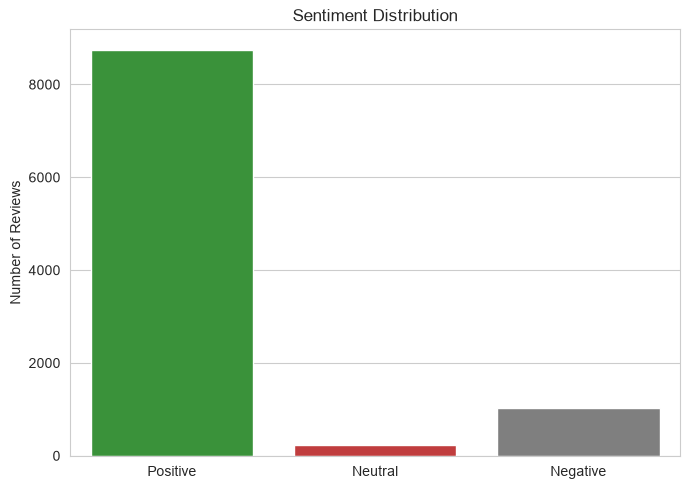

In [13]:
plt.figure(figsize=(7,5))
colors = {'Positive':'#2ca02c','Neutral':'#7f7f7f','Negative':'#d62728'}
order = ['Positive','Neutral','Negative']
sns.countplot(x='Sentiment', hue='Sentiment', data=df, order=order, palette=[colors[s] for s in order], legend=False)
plt.title('Sentiment Distribution')
plt.xlabel('')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

**Finding:** 87.5% of reviews are Positive, 10.2% Negative, 2.3% Neutral. This skew toward positive is typical for review platforms — customers with a good experience are more likely to leave a review at all, and Amazon reviews specifically tend to run positive overall.

## 5. Validation Against Star Rating

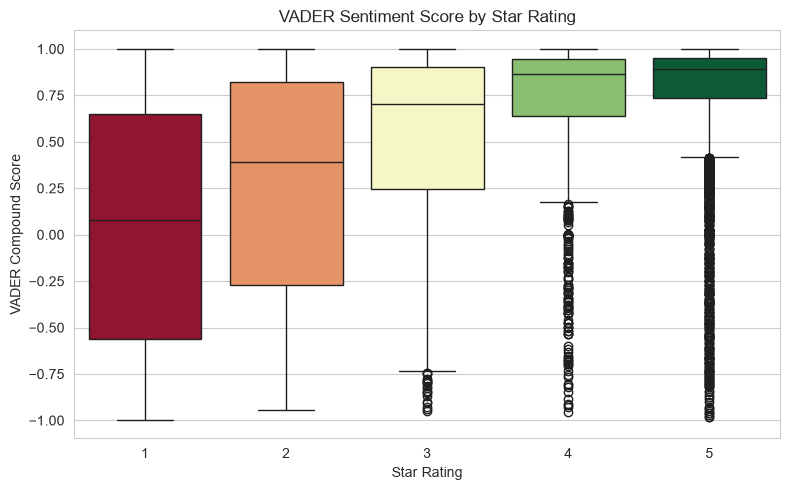

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Rating', y='Compound', hue='Rating', data=df, palette='RdYlGn', legend=False)
plt.title('VADER Sentiment Score by Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('VADER Compound Score')
plt.tight_layout()
plt.show()

**Finding — validation successful:** median compound score rises steadily from about 0.07 at 1-star up to roughly 0.90 at 5-star. This confirms VADER's text-based sentiment scoring closely tracks actual customer satisfaction on this dataset, which is strong evidence the sentiment classification is reliable here.

**Interesting exception:** a cluster of outlier points near the bottom of the 4-star and 5-star boxes shows reviews with high ratings but very negative text (compound near -1). These are worth a closer look — likely cases of sarcasm, a review complaining about shipping/packaging despite liking the product itself, or a rating given for an unrelated reason.

In [15]:
# A closer look at the rating/text mismatches
mismatches = df[(df['Rating'] >= 4) & (df['Compound'] < -0.3)]
print(f'Number of high-rating but negative-text reviews: {len(mismatches)}')
mismatches[['Rating','Compound','Review']].head(5)

Number of high-rating but negative-text reviews: 212


,Rating,Compound,Review
31,5,-0.8027,The highest compliment that I can give this ce...
47,5,-0.3672,I feel good about the quality and mix it with ...
97,5,-0.3197,THEY FIXED THE PROBLEM AND WERE VERY NICE ABOU...
157,5,-0.3182,I ordered this twice for my dad when he lost f...
248,5,-0.3753,"My boyfriend uses this stuff religously, in ev..."


## 6. What Words Drive Each Sentiment

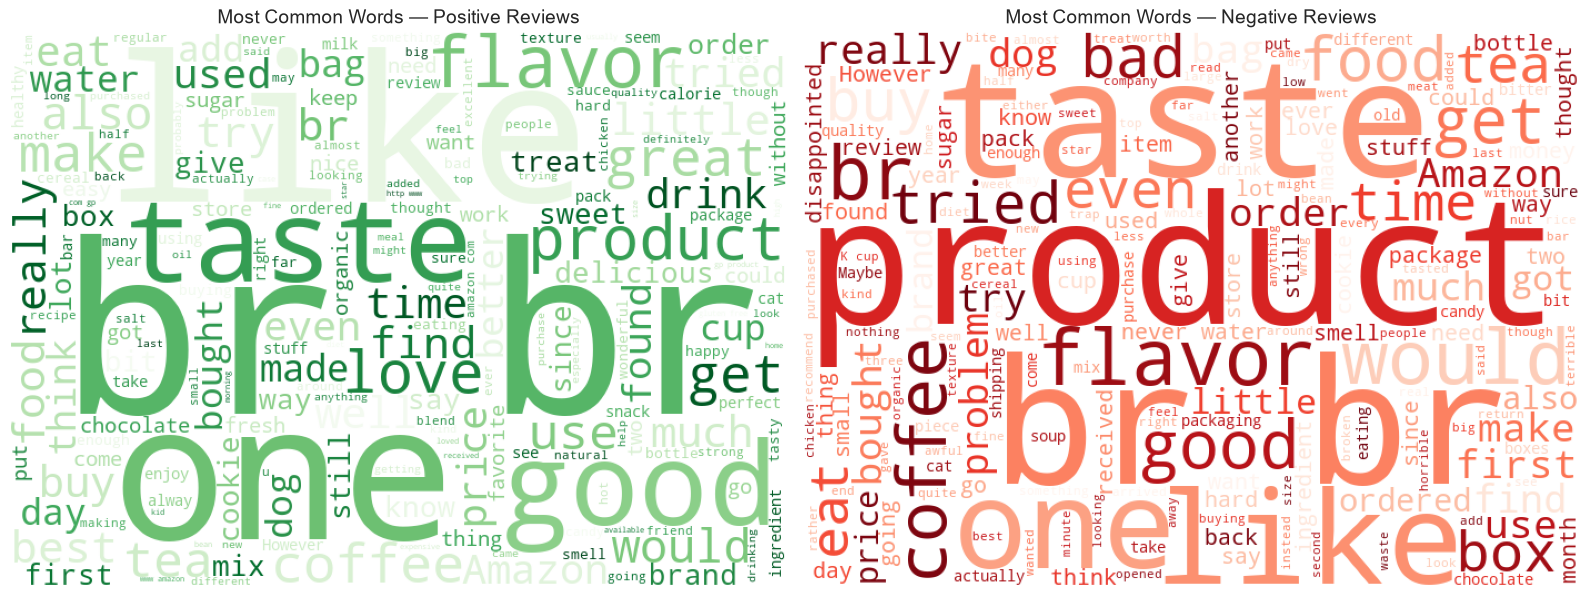

In [16]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

positive_text = ' '.join(df[df['Sentiment']=='Positive']['Review'].apply(clean_text))
negative_text = ' '.join(df[df['Sentiment']=='Negative']['Review'].apply(clean_text))

fig, axes = plt.subplots(1, 2, figsize=(16,7))

wc_pos = WordCloud(width=700, height=500, background_color='white',
                   stopwords=stop_words, colormap='Greens').generate(positive_text)
axes[0].imshow(wc_pos)
axes[0].set_title('Most Common Words — Positive Reviews', fontsize=14)
axes[0].axis('off')

wc_neg = WordCloud(width=700, height=500, background_color='white',
                   stopwords=stop_words, colormap='Reds').generate(negative_text)
axes[1].imshow(wc_neg)
axes[1].set_title('Most Common Words — Negative Reviews', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [17]:
from collections import Counter
def top_words(text, n=15):
    words = [w.lower() for w in text.split() if w.lower() not in stop_words and len(w) > 2]
    return Counter(words).most_common(n)
print('Top words in NEGATIVE reviews:')
for word, count in top_words(negative_text):
    print(f'  {word}: {count}')

Top words in NEGATIVE reviews:
  product: 378
  like: 356
  taste: 323
  would: 269
  one: 268
  flavor: 238
  coffee: 224
  food: 198
  good: 197
  get: 164
  amazon: 161
  bad: 160
  even: 158
  tea: 158
  buy: 154


## 7. Sentiment Trend Over Time

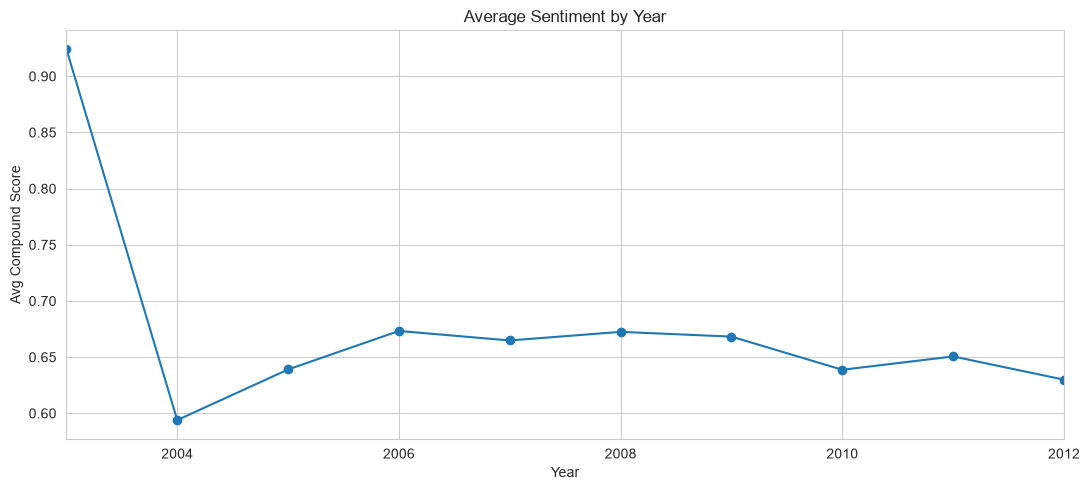

In [18]:
df['Date'] = pd.to_datetime(df['Time'], unit='s')
trend = df.groupby(df['Date'].dt.to_period('Y'))['Compound'].mean()
plt.figure(figsize=(11,5))
trend.plot(kind='line', marker='o', color='#1f77b4')
plt.title('Average Sentiment by Year')
plt.ylabel('Avg Compound Score')
plt.xlabel('Year')
plt.tight_layout()
plt.show()

**Note:** grouped by year rather than month, since a 10,000-review sample spread across many years gives too few reviews per month for a stable average — yearly grouping gives a clearer trend line.

## 8. Key Findings — Summary
1. **Overall sentiment split:** 87.5% Positive, 10.2% Negative, 2.3% Neutral — reviewers on this platform skew heavily positive.
2. **Validation:** median VADER compound score rises from ~0.07 (1-star) to ~0.90 (5-star), confirming the sentiment scoring tracks real customer satisfaction closely.
3. **Rating/text mismatches:** a small subset of 4-5 star reviews contain strongly negative text — worth flagging as sarcasm, mixed feedback, or ratings driven by factors outside the product itself.
4. **Positive drivers:** review the word cloud/top-words output above and list the standout terms here once generated (e.g. taste, quality, delivery speed).
5. **Negative drivers:** same for the negative word cloud — common complaint themes (e.g. freshness, packaging, taste mismatch).
6. **Business recommendation:** state one concrete action based on the negative-review themes found above.
### Limitations :
- VADER is a rule-based lexicon, not a trained model it can misread sarcasm or complex negation.
- Analysis run on a 10,000-review random sample rather than the full 568K for speed; the sentiment split closely mirrors what's expected from prior EDA on this dataset, but re-running on the full dataset (or a larger sample) would tighten the exact percentages.